POSYDON Summer School 2026 <br />
Initial Final Interpolation Tutorial <br />
Prepared by Philipp M. Srivastava <br />

In [1]:
from posydon.grids.psygrid import PSyGrid
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from utils import show_figure

**Introduction**
As a POSYDON user, you may wonder how we simulate binaries that are not only accurate, but also efficient enough to enable the synthesis of populations containing millions of binaries. Among other factors, the main reason for our efficiency without sacrificing accuracy is the use of highly accurate machine learning (ML) systems. The most prevalent of these systems is the so-called initial-final interpolator. To understand this naming convention, let's begin by examining the steps within a typical binary evolution. The figure below shows just one possibility of the many different evolutionary possibilties, and each possible step within binary evolution is typically quite computationally expensive. In this particular example the two stars both start in a Hydrogen burning phase, until one of them enters a Helium burning phase causing mass transfer and then a collapse into a black hole via super nova, yielding a high mass X-ray binary. Next, the black hole and its companion enter a common envelope stage prior to the companion entering its own Helium burning phase with mass transfer. Finally, the companion collapses into a pulsating neutron star which merges with its companion black hole, emitting gravitational waves detectable to us. So how can we go about modelling so many physically rich and thereby computationally expensive steps efficiently?

Source: [1]


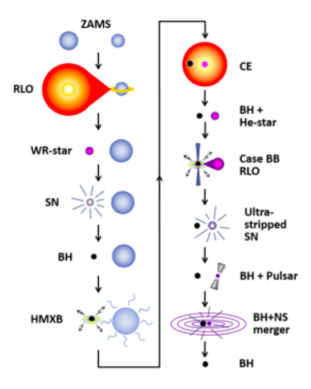

In [2]:
show_figure("binary_evolution.png", "[1]")

The key is to notice that most evolutionary paths are comprised of two main components: first, relatively long periods of time during which the stars or celestial objects undergo stellar evolution with binary interactions, and second, relatively short periods of time when the binary system undergoes violent and defining changes. While the latter steps usually consist of very rich physical processes that must be modelled with carefully constructed prescriptions, the former can be modelled by employing ML models which can effectively skip these phases by predicting binary's final values (stellar masses, orbital period, etc.), given its values at the beginning of each phase. For this, we define a total of three phases which a binary could enter and are modelled by a ML system:

1. HMS-HMS, when both stars begin at the zero age main sequence (ZAM) and undergo Hydrogen burning.
2. CO-HMS RLO, when the primary star is burnig Hydrogen and is in a roche lobe overflow (RLO) state with its companion which has collapsed into a compact object.
3. CO-HeMS, when the primary star is burning Helium while its companion has collapsed into a compact object.

Employing this paradigm, the first figure evolves into the one given below. Notice that each of the phases has been replaced with two bars, a pink one and a purple one. The pink represents the parameters describing the celestial objects at the beginning of the phase, while the purple one correspoonds to those parameters at the end of the phase.

Source: [1]


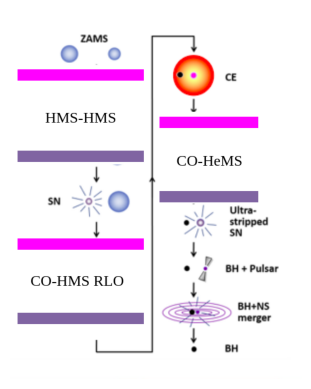

In [3]:
show_figure("./binary_evolution_with_IF.png", "[1]")

**Theoretical descriprion of the initial-final interpolator** <br />
The initial-final interpolation problem can conveniently be viewed as a regression problem, which has been well-studied in the ML community. In order to solve the problem, each of the mentioned three phases are modelled repeatedly using the famous code modules for experiments in stellar astrophysics (MESA) [], where for eachy system modelled, the initial masses and orbital period are varied. This sampling of initial values form a grid $G = \{\mathbf{i}_1, \mathbf{i}_2, \dots, \mathbf{i}_N\}$, where $\mathbf{i}_j = (M^j_1, M^j_2, P_{orb})$, (the primary mass, secondary mass, and orbital period), and $N$ is the number of initial values in $G$. It should be noted that, the initial values are sampled in $\log$  space, which yields a higher resolution in low mass and orbital period values. Physcally, this makes sense, because systems with a higher orbital period will have less binary interactions and therefore don't require as fine of a resolution. To predict the final values of a system with an initial value of $\mathbf{i}_*$, an intuitive approach is to take the linear combination of the final values corresponding to initial values in $G$ with the smallest euclidean distance to $\mathbf{i}_*$. However, based on the trajectory of the simulation, we can expect the final values to differ drastically. For example, often the process of computing the solutions with MESA becomes unstable during the mass transfer (MT) phase, which prompts the simulation to be stopped. Clearly those final values will be quite different from those PDE solutions during which instability was not an issue, and therefore, it does not make sense to take consider those final values together. To address this, we define a total of four classes:

1. Stable MT
2. Stable reverse MT
3. Unstable MT
4. No MT
5. Initial MT

With the initial MT class being one that we do not wish to find final values for. To solidify our understanding, let's take a look at the HMS-HMS grid and explore how we might address the problem of finding which linear combination of initial values we should take in order to compute final values.

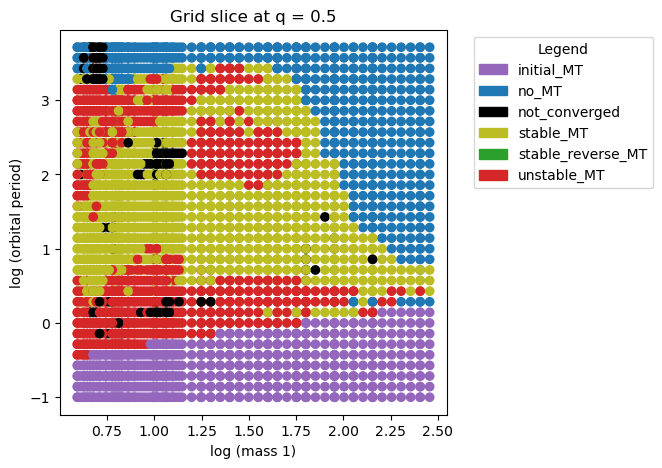

In [4]:
grid_path = "data/POSYDON_GRIDS/POSYDON_data/HMS-HMS/1e-01_Zsun.h5" # fill me in!

grid = PSyGrid(grid_path) # loading in grid
initial_values = np.array(grid.initial_values[["star_1_mass", "star_2_mass", "period_days"]].tolist())
mass_ratio = initial_values[:, 1] / initial_values[:, 0] # The HMS-HMS grid is sampled across mass ratio
class_labels = grid.final_values["interpolation_class"] # this contains an array where each elemnt is a class
# corresponding to each initial value
labels = np.unique(class_labels)

"""
defining which mass ratio our grid slice should correspond to and which delta deviation from that
grid slice is acceptable to consider an initial value part of the grid slice
"""
mr, delta = 0.5, 0.05

slice_inds = np.where((mass_ratio < mr + delta) & (mass_ratio > mr - delta)) # filtering to find slice
class_labels = class_labels[slice_inds] # filtering to get classes
label_colors = ["tab:purple", "tab:blue", "black", "tab:olive", "tab:green", "tab:red"]
color_dict = dict(zip(labels, label_colors)) # choose your colors

colors = [color_dict[label] for label in class_labels]

# plotting
fig, ax = plt.subplots(1, 1, figsize = (5, 5))

scatter = ax.scatter(
    np.log10(initial_values[:, 0][slice_inds]), # notice that we plot the initial values in log space
    np.log10(initial_values[:, 2][slice_inds]), c = colors)
ax.set_xlabel("log (mass 1)")
ax.set_ylabel("log (orbital period)")
ax.set_title(f"Grid slice at q = {mr}")

patches = [mpatches.Patch(color=color, label=label) for color, label in zip(label_colors, labels)]
legend = ax.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc="upper left", title="Legend")

To classify an initial value $\mathbf{i}_*$, we utilize a $k$-nearest neighbor approach, where $k$ is optimized using a validation set, and the weight of each neighbor $\mathbf{i}_j \in \mathscr{N}_*$ is set to be $d^-2$, where $d$ is the euclidean distance between the neighbor and the initial value of interest and $\mathscr{N}_*$ is the neighborhood of $\mathbf{i}_*$. $k$-nearest neighbors is widely known and a rather simple algorithm so we direct the reader to this [wikipedia page](https://en.wikipedia.org/wiki/K-nearest_neighbors_algorithm) for a refresher. Instead, we will focus on the more interesting process of the interpolation itself, which is carried out using barycentric interpolation, which is based on barycentric coordinates. Barycentric coordinates are defined with respect to a shape. Thus, we require a tesselation over our initial values, which are seperated by their assigned MT class. Although other tesselations could theoretically be used, Delaunay triangulation [] is a standard algorithm which is widely used, and results in a convex hull of simplices (an $n$-dimensional triangle). This results in each initial value of interest, $\mathbf{i}_*$, residing within a tetrahedral $T$, whose vertices belong to $G$, as seen in figure 3. The barycentric coordinates of $\mathbf{i}_*$ are then the set of weights that would need to be given to each vertex such that $\mathbf{i}_*$ would be the center of mass of the simplex.

Source: 


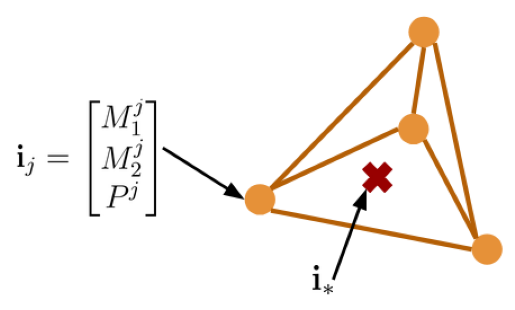

In [5]:
show_figure("barycentric_coordinates.png", "")

These coordinates can easily be computed by solving the set of 4 equations given below:

1. $\lambda_1 M_1^a + \lambda_2 M_1^b + \lambda_3 M_1^c + \lambda M_1^d = M_1^*$
2. $\lambda_1 M_2^a + \lambda_2 M_2^b + \lambda_3 M_2^c + \lambda M_2^d = M_2^*$
3. $\lambda_1 P^a + \lambda_2 P^b + \lambda_3 P^c + \lambda P^d = P^*$
4. $\sum_{i = 1}^4 \lambda_i = 1$

Let's implement this in numpy below!

In [23]:
def compute_barycentric_coordinates(point, coords):
    """ Function: compute_barycentric coordinates

        Parameter(s):

        point - np.ndarray: a 3 dimensional vector specifying the position of the point
        coords - np.ndarray: a 4 x 3 matrix where each row corresponds to a point in 3-d space
    """
    T = np.array([
        coords[0] - coords[3],
        coords[1] - coords[3],
        coords[2] - coords[3]
    ]) # our matrix
    T = T.T
    T_I = np.linalg.inv(T)

    r_a = point - coords[3]

    weights = (T_I @ r_a).tolist()

    weights.append(1 - weights[0] - weights[1] - weights[2])

    weights = np.array(weights) / sum(weights)

    return weights

coords = # fill me in!
point = # make sure I am in the tetrahedral!
weights = compute_barycentric_coordinates(point, coords)
print(f"The barycentric weights of our point are: {weights}")

The barycentric weights of our point are: [ 0.375  0.375 -0.75   1.   ]


**Optional**
Can you think of an edge-case for which the algorithm would be undefined? Propose an easy solution

<details>
<summary>Solution</summary>

$$
coords = \begin{pmatrix}
0 & 0 & 0 \\
1 & 0 & 0 \\
1/2 & 1 & 0 \\
1/2 & 1 & 1/2
\end{pmatrix}
$$

$$
point = \begin{pmatrix}
1/2 & 1/4 & 1/2 \\
\end{pmatrix}
$$

</details>

**Using our implementations** <br />
Now that we understand the inner workings of our ML methods, we will move on to how our implementations can used to perform binary simulations and any other systems that require a similar treatment. All implementations related to the ML components can be found in the `posydon.interpolation` module. From there, we can import the `IFInterpolator` class which contains the implementation which is described above, like so.

In [7]:
from posydon.interpolation.IF_interpolation import IFInterpolator

To construct the `IFInterpolator` class we need to specify two parameters:

1. `grid`: PSyGrid, this is a PSyGrid class instance which contains among other things two important attributes, `initial_values` and `final_values` which respectively correspond to the initial values used by MESA to find the solution to systems of partial differential equations (PDEs) describing the evolution of the binary and the final values which are the parameters describing each star system at the last time step of the solution found using MESA. Although these grids can be generated by a user familiar with the PSyGrid class, we highly recommend that the grids provided by the POSYDON collaboration are used which can be found in the POSYDON_data directory which should have been created during installation.
2. `interpolators`: list, this is a list of dictionaries, each of which contains the specifications to an interpolator. This is useful because we often want to specify a different classification scheme for different parameters (more on this later).

Next, we specify the parameters required by each individual interpolator:

1. `interp_method`: list, the interpolation method to be used can be either
linear, 1NN, or a list specifying which interpolation method to
be used for each type of track. If interp_classes is specified and this
parameter is not a list then the interpolator will use the specified method
for all classes.

2. `interp_classes`: list, a list of classes that the simulation tracks can
fall into. Usually specified as the mass transfer type. This only needs
be specified if interp_method is a list. Note that when using class-wise normalization 
only classes in interp_classes are normalized. This is the behavior for interpolation normalization
but not classification normalization.

3. `class_method`: str, the classification method to be used, either kNN or
1NN.

4. `in_keys`: list, the keys to be used as the input to the interpolator (initial_values), by default
these are star_1_mass, star_2_mass, and period_days.

5. `out_keys`: list, the keys for which the interpolator is supposed to provide values (final_values),
by default all keys are used.

6. `in_scaling`, list: The scalings for the input keys, by default these scalings are
optimized through Monte Carlo Cross Validation.

7. `out_scaling`, list: The scalings for the output keys, by default these scalings
are optimized through Monte Carlo Cross Validation.

8. `c_keys`, list: A list of strings specifying which classifiers are to be trained

9. `c_key`, str: A string specifying by which class the interpolator should
interpolate binaries. Only to be specified in the MCInterpolator case.

Now, let's use these parameters to construct and train our own instance of the `IFInterpolator`!

In [16]:
interp = IFInterpolator(grid = grid, interpolators = [
        {
            "interp_method": ["linear", "linear", "linear"],
            "interp_classes": ["no_MT", "stable_MT", "unstable_MT"], # classes not in this array will not be normalized in class-wise normalization
            "out_keys": ["star_1_mass"],
            "class_method": "kNN",
            "c_keys": ["interpolation_class"],
            "c_key": "interpolation_class"
        }
    ]
)

interp.train()

Discarded 987 binaries with interpolation_class = [not_converged]
Discarded 0 binaries with interpolation_class = [ignored_no_RLO]
Discarded 0 binaries with interpolation_class = [ignored_no_binary_history]
Discarded 0 binaries with nans in input values.

Nans in numerical variables:
[i_MT] =   754, [no_MT] =     0, [st_MT] =     0, [u_MT] =     0 :   0 star_1_mass

[i_MT] =  7297, [no_MT] =  7007, [st_MT] = 11398, [u_MT] =   420

Nones in categorical variables:

[i_MT] =  7297, [no_MT] =  7007, [st_MT] = 11398, [u_MT] =   420

Filling missing values (nans) with 1NN

Training kNN classifier for interpolation_class [nclasses = 5]...
 - [7297] initial_MT
 - [7007] no_MT
 - [11398] stable_MT
 - [420] stable_reverse_MT
 - [12603] unstable_MT


/opt/conda/envs/posydon_env/lib/python3.11/site-packages/posydon/interpolation/IF_interpolation.py:1479: InterpolationWarning: 'normalization was skipped during interpolation: c=stable_reverse_MT, inds=[  504   584  1023  1087  1167  1194  1204  1253  1265  1421  1635  1686\n  1750  1760  1810  1949  1978  2014  2037  2167  2207  2342  2676  2956\n  3007  3145  3169  3212  3220  3295  3326  3344  3468  3481  3552  3702\n  3717  3935  3991  4002  4040  4103  4148  4204  4241  4279  4364  4390\n  4438  4599  4600  4668  4686  4693  4722  4740  4745  4748  4755  4766\n  4840  4919  4951  4958  4967  5141  5286  5288  5303  5336  5372  5380\n  5521  5739  5765  5919  5979  5984  6014  6066  6076  6130  6141  6142\n  6206  6289  6376  6703  6712  6783  6850  6863  6968  7020  7034  7121\n  7140  7162  7275  7323  7346  7356  7372  7419  7440  7502  7558  7559\n  7635  7657  7715  7735  7800  7862  7897  7904  7962  7972  7975  7981\n  8032  8115  8133  8160  8171  8193  8195  8252  8298  83

To use the interpolator we have a few methods available to us which are listed below:

1. `IFInterpolator.evaluate`: this is the method used by the posydon library but requires an instantiation of the `BinaryStar` class.
2. `IFInterpolator.test_interpolator`: this is the method that is fastest for interpolating binaries and requires an $n \times d$ array where $d$ is the number of initial values (by default 3).
3. `IFInterpolator.test_classsifiers`: this is the method to use when wanting to only use the classification capabilities of the `IFInterpolator`. It requires the same input as `IFInterpolator.test_interpolator` and returns a dictionary where each key is a classification scheme and the value is the class predicted. We haven't explained the classification schemes in detail, but in short, we may want to classify our binary systems based on different criterion, each of which we refer to as a classification scheme. For example, the most commonly used classification scheme involves classifying by MT type, but we might also want to classify by which compact object one of the stars collapses into (either a white dwarf, neutron star, or black hole).

Below is a quick demonstration.

In [17]:
# some quick imports to use the evaluate class
from posydon.binary_evol.singlestar import SingleStar
from posydon.binary_evol.binarystar import BinaryStar

Zsun = 1.

kwargs1 = {"state" : "H-rich_Core_H_burning",
           "mass" : 20.0,
           "metallicity" : Zsun}

star_1 = SingleStar(**kwargs1)

kwargs2 = {"state" : "H-rich_Core_H_burning",
           "mass" : 10.0,
           "metallicity" : Zsun}

star_2 = SingleStar(**kwargs2)

kwargs3 = {"state" : "detached",
           "event" : None,
           "time" : 0.,
           "orbital_period" : 3.,
           'eccentricity' : 0.}

binary = BinaryStar(star_1, star_2, **kwargs3)

In [18]:
i, c = interp.evaluate(binary)
i, c = i["star_1_mass"], c["interpolation_class"]

initial_value = np.array([[20, 10, 3]])

i2 = interp.test_interpolator(initial_value)
c2 = interp.test_classifiers(initial_value)["interpolation_class"][0]

print(
    f"Interpolation for initial value {initial_value}: {i}, {i2[0, 0]} \nClassification for initial value: {c}, {c2}"
)

Interpolation for initial value [[20 10  3]]: 12.626519688836542, 5.538037007592811 
Classification for initial value: unstable_MT, unstable_MT


/opt/conda/envs/posydon_env/lib/python3.11/site-packages/posydon/interpolation/data_scaling.py:127: RuntimeWarning: divide by zero encountered in log10
/opt/conda/envs/posydon_env/lib/python3.11/site-packages/posydon/interpolation/IF_interpolation.py:1532: RuntimeWarning: invalid value encountered in cast
/opt/conda/envs/posydon_env/lib/python3.11/site-packages/posydon/interpolation/IF_interpolation.py:1177: InterpolationWarning: '1NN interpolation used for 1 binaries out of hull. Parameter-wise distance (Unnormalized) for point with maximum out-of-hull euclidian distance (Normalized): [2.95451507e+01 4.33498486e+18 2.97947468e+01]'


Lastly, we can also save the our `IFInterpolator` instantiation using the `IFInterpolator.save` method like so.

In [19]:
interp.save("./my_first_interpolator_:).pkl")

Naturally, we can also load in saved instances of the `IFInterpolator` class. Before we load in a class instance which is used within POSYDON, let's discuss the differences in the parameters used to construct an interpolator we use within a binary simulation and the interpolator that we just constructed, trained, and saved. First and foremost, within simulations carried out with POSYDON we are interested in more parameters than just the `star_1_mass`. In fact, we interpolate all final values available to us. However, they are not all interpolated by one interpolator because we want to interpolate different final value parameters with different classification schemes. The vast majority of parameters are interpolated with a MT classification scheme, which is introduced in section XX while the remaining parameters are grouped by super nova (SN) models, resulting in each SN model being treated with its own classification scheme. A pictoral representation of this system can be seen in figure 4.

Source: [2]


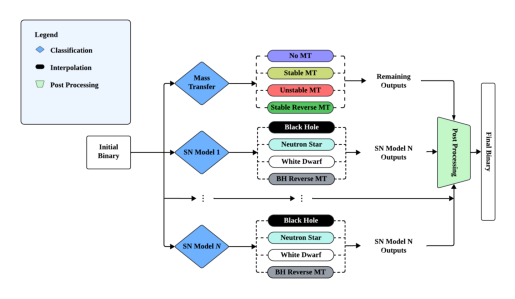

In [20]:
show_figure("./initial_final.png", source="[2]")

Let's load in one of the interpolators we actually use within POSYDON!

In [21]:
interp_path = # fill me in
interp = IFInterpolator()

interp.load(interp_path)

SyntaxError: invalid syntax (3523448293.py, line 1)

Feel free to play around with the functionality we introduced in the tutorial below.

**Concluding Remarks**
Although simple, the algorithms presented within this tutorial are also very interpetable and quite powerful when paired with our high resolution grids. They are also not limited to applications within POSYDON and can be extended to solve any sort of problem that can be formulated as a regression task, particularly those that require a highly interpretable system. Therefore, we encourage users to use our code not only for POSYDON relatedd tasks, but also for any project that requires the functionality this system provides. Furthermore, we are always happy to assist users in using our software and thus, if any help is desired from our team, please do not hesitate to reach out.

References <br /> <br />
[1] Tauris, T. M. and van den Heuvel, E. P. J., Physics of Binary Star Evolution. From Stars to X-ray Binaries and Gravitational Wave Sources. 2023. doi:10.48550/arXiv.2305.09388. <br />
[2] Andrews, J. J., “POSYDON Version 2: Population Synthesis with Detailed Binary-Evolution Simulations across a Cosmological Range of Metallicities”, arXiv e-prints, Art. no. arXiv:2411.02376, 2024. doi:10.48550/arXiv.2411.02376.

